In [1]:
# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [2]:
# loading dataset

df = pd.read_csv("train4.csv")

# first 5 rows

print(df.head())

# dataset information

print(df.shape)

print(df.dtypes)

print(df.isnull().sum())

   Unnamed: 0   Loan_ID  Gender Married Dependents     Education  \
0           0  LP002305  Female      No          0      Graduate   
1           1  LP001715    Male     Yes         3+  Not Graduate   
2           2  LP002086  Female     Yes          0      Graduate   
3           3  LP001136    Male     Yes          0  Not Graduate   
4           4  LP002529    Male     Yes          2      Graduate   

  Self_Employed  ApplicantIncome  CoapplicantIncome  LoanAmount  \
0            No             4547                0.0       115.0   
1           Yes             5703                0.0       130.0   
2            No             4333             2451.0       110.0   
3           Yes             4695                0.0        96.0   
4            No             6700             1750.0       230.0   

   Loan_Amount_Term  Credit_History Property_Area  Loan_Status  
0             360.0             1.0     Semiurban            1  
1             360.0             1.0         Rural         

In [3]:
# removing unnecessary columns

df = df.drop(['Unnamed: 0', 'Loan_ID'], axis=1)

# filling categorical missing values with mode

df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

df['Married'] = df['Married'].fillna(df['Married'].mode()[0])

df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])

df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

# filling numerical missing values with mean

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())

df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean())

df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mean())

# checking missing values again

print(df.isnull().sum())

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


Loan_Status
1    343
0    148
Name: count, dtype: int64


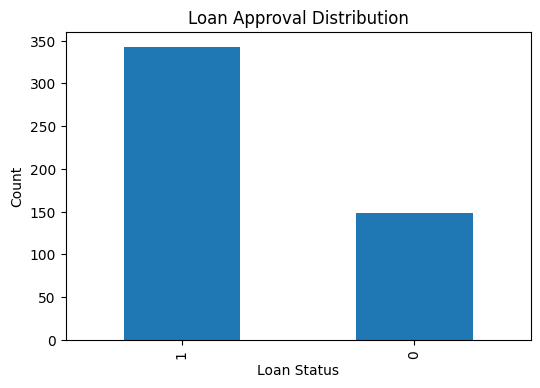

In [4]:
# checking target value counts

print(df['Loan_Status'].value_counts())

# plotting loan status distribution

plt.figure(figsize=(6,4))

df['Loan_Status'].value_counts().plot(kind='bar')

plt.title("Loan Approval Distribution")

plt.xlabel("Loan Status")

plt.ylabel("Count")

plt.show()

In [5]:
# encoding categorical columns

le = LabelEncoder()

for column in df.columns:
    
    if df[column].dtype == 'object' or df[column].dtype == 'str':
        
        df[column] = le.fit_transform(df[column])

# selecting input and target columns

X = df.drop('Loan_Status', axis=1)

y = df['Loan_Status']

# feature scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# checking shapes

print(X_train.shape)

print(X_test.shape)

(392, 11)
(99, 11)


In [6]:
# logistic regression model

lr = LogisticRegression(class_weight='balanced')

# training model

lr.fit(X_train, y_train)

# predictions

y_pred_lr = lr.predict(X_test)

# evaluation

print("Logistic Regression Results")

print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("Precision:",
      precision_score(y_test, y_pred_lr))

print("Recall:",
      recall_score(y_test, y_pred_lr))

print("F1 Score:",
      f1_score(y_test, y_pred_lr))

Logistic Regression Results
Accuracy: 0.8080808080808081
Precision: 0.8194444444444444
Recall: 0.9076923076923077
F1 Score: 0.8613138686131386


In [7]:
# decision tree classifier

dt = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

# training model

dt.fit(X_train, y_train)

# predictions

y_pred_dt = dt.predict(X_test)

# evaluation

print("Decision Tree Results")

print("Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print("Precision:",
      precision_score(y_test, y_pred_dt))

print("Recall:",
      recall_score(y_test, y_pred_dt))

print("F1 Score:",
      f1_score(y_test, y_pred_dt))

Decision Tree Results
Accuracy: 0.6868686868686869
Precision: 0.7931034482758621
Recall: 0.7076923076923077
F1 Score: 0.7479674796747967


In [8]:
# random forest classifier

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

# training model

rf.fit(X_train, y_train)

# predictions

y_pred_rf = rf.predict(X_test)

# evaluation

print("Random Forest Results")

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1 Score:",
      f1_score(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.7777777777777778
Precision: 0.7792207792207793
Recall: 0.9230769230769231
F1 Score: 0.8450704225352113


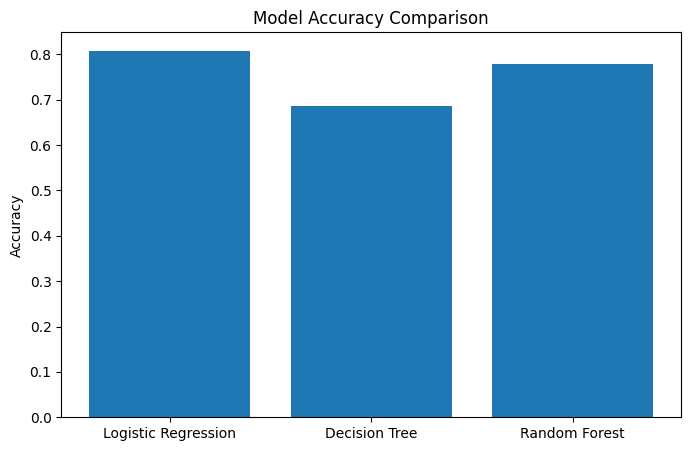

In [9]:
# comparing model accuracies

models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest'
]

accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf)
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

# Conclusion

In this project, loan approval prediction was performed using different machine learning classification models.

The dataset was cleaned and preprocessed by handling missing values, removing unnecessary columns, encoding categorical variables, scaling numerical features, and dealing with imbalanced data using balanced class weights.

Three machine learning models were trained and compared:

* Logistic Regression
* Decision Tree Classifier
* Random Forest Classifier

Among all models, Logistic Regression achieved the best overall performance with the highest accuracy and F1 score.

This project helped in understanding:

* missing value handling
* imbalanced data handling
* categorical encoding
* feature scaling
* classification models
* model evaluation
* comparison of machine learning algorithms

The project also demonstrated how machine learning can be used in loan approval prediction systems.
